# Single Layer Case

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
#from czt import time2freq, freq2time
from scipy.optimize import curve_fit


## Most basic: functions and variables

In [2]:
epsilon_0 = 8.854E-12 # F/m
mu_0 = np.pi*4.0E-7 # H/m
c = 3.0E08 # m/s
lam1 = 450e-9+0.0j
#h0 = h1
theta0 = np.pi/6
h1 = 10e-9
n0 = 1.0+0.0j
n1 = 1.5+0.0j
e_x = np.array([1.0+0.0j,0.0+0.0j,0.0+0.0j])
e_y = np.array([0.0+0.0j,1.0+0.0j,0.0+0.0j])
e_z = np.array([0.0+0.0j,0.0+0.0j,1.0+0.0j])
norm_vec = np.array([0,0,1])
num = 10**8

def TtoS(mat):  # to scattering matrix, diagonal terms are reflection coefficients.
    [[m11,m12],[m21,m22]]=mat
    [[r12,t21],[t12,r21]]=[[-m21/m22,1/m22],[m11-m12*m21/m22,m12/m22]]
    return np.array([[r12,t21],[t12,r21]])

def StoT(co):  # to transfer matrix, 
    [[r12,t21],[t12,r21]]=co
    [[m11,m12],[m21,m22]]=[[(t12- r12*r21/t21),r21/t21],[-r12/t21,1/t21]]
    return np.array([[m11,m12],[m21,m22]])

def totalST(layers):
    t=np.identity(2)
    for lay in layers:
        t0=StoT(lay)
        t=t0@t
    s=TtoS(t)
    return s,t    

Recall that the T matrices are not causal. You do not have a simple physical input-output relation. You need to know the future in order to be able to use them. Meanwhile, the S matrices are causal: you give input fields anf get output fields.

## Setting up the EM Wave

In [3]:
def k_vector(theta, lam):
    k_vec = 2*np.pi/lam*np.array([np.sin(theta),0,np.cos(theta)])
    return k_vec
               
def k_j(ki,ni,nj):
    kj = np.array([ki[0],ki[1],np.sqrt(ki[2]**2+np.dot(ki,ki.conj())*((nj/ni)**2-1))])
    return kj

def gen_E_amp(E_par,E_perp):
    return np.array([complex(E_par),complex(E_perp),0.0+0.0j])

def E_avi_decomp(E_avi,ki):
    E_avsi = E_avi[1] * e_y
    E_avpi = E_avi[0] * np.cross(ki/np.sqrt(np.dot(ki,ki)),e_y)
    #proper_E_avi = E_avsi + E_avpi
    return E_avsi,E_avpi

ki0 = k_vector(np.pi/6,lam1)

## Setting up the Simulation

In [4]:
def medium(k_vec,h):  # scattering matrix, diagonal terms are reflection coefficients.
    # k_vec is a 3D vector
    rij=0
    rji=0
    tij=np.exp(1j*k_vec[2]*h)
    tji=np.exp(1j*k_vec[2]*h)
    return np.array([[rij,tji],[tij,rji]])

def interface_s(ki,kj):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    kzi = ki[2]
    kzj = kj[2]
    if np.iscomplex(kzj):
        raise ValueError("Total internal reflection going ij")
    rij = (kzi - kzj)/(kzi + kzj)
    rji = -rij
    tij = 1 + rij #2*kzi/(kzi + kzj)
    tji = 1 + rji #2*kzj/(kzi + kzj)
    # print(1/kzi*(kzi*np.abs(rij)**2+kzj*np.abs(tij)**2))
    # print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def interface_p(ki,kj):  # scattering matrix, p-polarised, diagonal terms are reflection coefficients.
    kzi = ki[2]
    kzj = kj[2]
    ki_a = np.sqrt(np.dot(ki,ki.conj()))
    kj_a = np.sqrt(np.dot(kj,kj.conj()))
    if np.iscomplex(kzj):
        raise ValueError("Total internal reflection going ij")
    rij = (kzi/ki_a**2 - kzj/kj_a**2)/(kzi/ki_a**2 + kzj/kj_a**2)
    rji = -rij
    tij = 2*kzi/((kj_a/ki_a)*kzi + (ki_a/kj_a)*kzj)
    tji = kzj/kzi * tij # 2*kzj/((ni/nj)*kzj + (nj/ni)*kzi)
    # print(1/kzi*(kzi*np.abs(rij)**2+kzj*np.abs(tij)**2))
    # print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def m_p(ki,kj,hi,hj):
    layers_p =[medium(ki,hi/2),interface_p(ki,kj),medium(kj,hj),interface_p(kj,ki),medium(ki,hi/2)]
    sp,mp = totalST(layers_p) 
    #print(np.abs(sp[0][0])**2+np.abs(sp[0][1])**2)
    #print(np.abs(sp[1][0])**2+np.abs(sp[1][1])**2)
    return sp,mp

def m_s(ki,kj,hi,hj):
    layers_s =[medium(ki,hi/2),interface_s(ki,kj),medium(kj,hj),interface_s(kj,ki),medium(ki,hi/2)]
    ss,ms = totalST(layers_s)
    #print(np.abs(ss[0][0])**2+np.abs(ss[0][1])**2)
    #print(np.abs(ss[1][0])**2+np.abs(ss[1][1])**2)
    return ss,ms

def multilayers_m(ki,kj,hi,hj,num_layers):
    M_s = np.linalg.matrix_power(m_s(ki,kj,hi,hj)[1],num_layers)
    M_p = np.linalg.matrix_power(m_p(ki,kj,hi,hj)[1],num_layers)
    return M_s, M_p

def M_eff(ki,kj,hi,hj,num_layers):
    #M_s, M_p = multilayers_m(ki,kj,hi,hj,num_layers)
    ms = m_s(ki,kj,hi,hj)[1]
    mp = m_p(ki,kj,hi,hj)[1]
    e_val_s, U_T_s = np.linalg.eig(ms)
    e_val_p, U_T_p = np.linalg.eig(mp)
    return U_T_s,U_T_p #[e_val_s,U_T_s],[e_val_p,U_T_p]

def embedded_structure(elements_s_form,num_elements):
    if len(elements_s_form) != len(num_elements):
        raise ValueError("elements_s_form and num_elements must have the same length.")
        return
    emb = 0
    for i in range(len(elements_s_form)):
        if i == 0:
            emb = conc_mat(elements_s_form[i], num_elements[i])
        else:
            emb = np.concatenate((emb, conc_mat(elements_s_form[i], num_elements[i])))
    return emb

def a_0_b_0(E_avi,ki,kj,hi,hj,num_layers):
    E_avsi, E_avpi = E_avi_decomp(E_avi,ki)
    proper_E_avi = E_avsi + E_avpi
    UTs, UTp = M_eff(ki,kj,hi,hj,num_layers)
    Seff_s = TtoS(UTs)
    Seff_p = TtoS(UTp)
    proper_E_av_b0 = E_avsi*Seff_s[1][0] + E_avpi*Seff_p[1][0]
    # kr = np.array([ki[0],ki[1],-ki[2]])
    return proper_E_avi, proper_E_av_b0 #, kr

def conc_mat(mat,num):
    if num == 1:
        mat_num = np.array([mat])
    else:
        mat_num = np.concatenate(([mat],[mat]))
        for i in range(num-2):
            mat_num = np.array(np.concatenate((mat_num,[mat])))
    return mat_num

def eff_n(ki,perM,hi,hj):
    evs = np.linalg.eig(perM)[0]
    kz = np.log(evs[0])/(1j*(hi+hj))
    neff = np.real(np.sqrt((ki[0]**2+ki[1]**2+kz**2)/np.dot(ki,ki.conj())))
    return neff

def field_n_layer(proper_E_avi,proper_E_av_b0,M_f_s,M_f_p):
    E_f_s = (M_f_s[0][0] + M_f_s[1][0]) * proper_E_avi[1] + (M_f_s[0][1] + M_f_s[1][1]) * proper_E_av_b0[1]
    E_f_px = (M_f_p[0][0] + M_f_p[1][0]) * proper_E_avi[0] + (M_f_p[0][1] + M_f_p[1][1]) * proper_E_av_b0[0]
    E_f_pz = (M_f_p[0][0] + M_f_p[1][0]) * proper_E_avi[2] + (M_f_p[0][1] + M_f_p[1][1]) * proper_E_av_b0[2]
    E_f = np.array([E_f_px,E_f_s,E_f_pz])
    return E_f

## Momentum

In [22]:
def stress_tensor(E_av_proper,ki): # We always evaluate in vacuum
    omega = np.sqrt(c**2*np.dot(ki, ki.conj()))
    H_av_proper = -1/(mu_0*omega)*np.cross(ki, E_av_proper)
    E_ij = 0.5 * epsilon_0 * (np.tensordot(E_av_proper.conj(),E_av_proper,axes=0) \
                              + np.tensordot(E_av_proper,E_av_proper.conj(),axes=0)) - \
    0.5 * epsilon_0 * np.dot(E_av_proper.conj(),E_av_proper) * np.eye(3)
    H_ij = 0.5 * mu_0 * (np.tensordot(H_av_proper.conj(),H_av_proper,axes=0) \
            + np.tensordot(H_av_proper,H_av_proper.conj(),axes=0)) - \
            0.5 * mu_0 * np.dot(H_av_proper.conj(),H_av_proper) * np.eye(3)
    return E_ij + H_ij

def z_momentum_layers(E_avi,ki,f,num_layers=num,ni=n0,nj=n1,hi=h1,hj=h1):
    kj = k_j(ki,ni,nj)
    proper_E_avi, proper_E_av_b0 = a_0_b_0(E_avi,ki,kj,hi,hj,num_layers)
    pz_as = np.empty(0)
    for n in range(f):
        Mfs,Mfp = multilayers_m(ki,kj,hi,hj,n)
        E_n = field_n_layer(proper_E_avi,proper_E_av_b0,Mfs,Mfp)
        pz = stress_tensor_f(E_n,ki)@norm_vec
        pz_as = np.append(pz_as,np.sqrt(np.dot(pz.conj(),pz)))
    pz_as = pz_as/pz_as[0]
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Normal Momentum Flux (normalised)')
    plt.title('Momentum Flux Over Layers')
    plt.plot(np.arange(f),pz_as)
    plt.grid(True)
    plt.show()

# Mathematica

## Finite structure of 60 periods

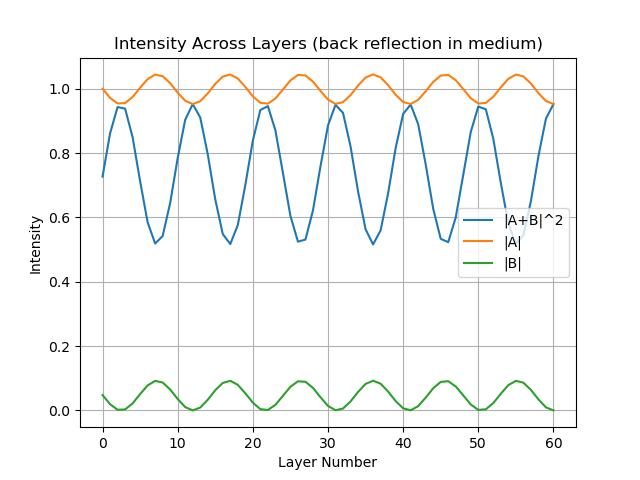

In [6]:
amplis = []
nper = 60
hi = h1
hj = h1
perM = m_s(ki0,k_j(ki0,n0,n1),hi,hj)[1]
stot = TtoS(StoT(interface_s(ki0,k_j(ki0,n0,n0)))@multilayers_m(ki0,k_j(ki0,n0,n1),hi,hj,nper)[0]@StoT(interface_s(ki0,k_j(ki0,n0,n0))))
a0 = 1
[b0, an] = stot@np.array([a0, 0])
eg = np.abs(b0)**2 + np.abs(an)**2 
amps = np.array([a0, b0])
m = np.eye(2)
amplis.append(amps)
for i in range(nper):
    m = perM@m
    amplis.append(m@amps)

plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity') # In the middle between two periods (free space)
plt.title('Intensity Across Layers (back reflection in medium)')
A = np.empty(nper+1)
B = np.empty(nper+1)
A = A.astype(np.complex128)
B = B.astype(np.complex128)
for i in range(nper+1):
    A[i] = amplis[i][0]
    B[i] = amplis[i][1]
plt.plot(np.arange(nper+1),np.abs(A+B)**2, label = '|A+B|^2')
plt.plot(np.arange(nper+1),np.abs(A)**2, label = '|A|')
plt.plot(np.arange(nper+1),np.abs(B)**2, label = '|B|')
plt.grid(True)
plt.legend()
plt.show()

## First 60 periods of an semi-infinite structure

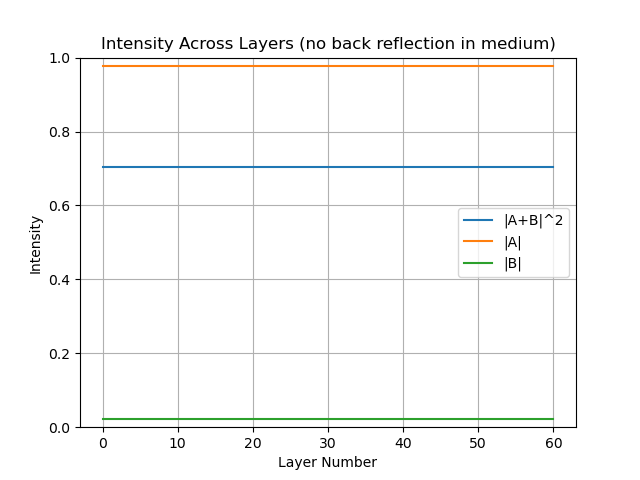

In [7]:
ev = np.linalg.eig(perM)[1]
#print(ev)
amps = ev[0] # Need some input from the other end to cancel back reflections
m = StoT(interface_s(ki0,k_j(ki0,n0,n0)))
amplis = []
amplis.append(amps)
for i in range(nper):
    m = perM@m
    amplis.append(m@amps)
plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity')
plt.title('Intensity Across Layers (no back reflection in medium)')
A = np.empty(nper+1)
B = np.empty(nper+1)
A = A.astype(np.complex128)
B = B.astype(np.complex128)
for i in range(nper+1):
    A[i] = amplis[i][0]
    B[i] = amplis[i][1]
plt.plot(np.arange(nper+1),np.abs(A+B)**2, label = '|A+B|^2')
plt.plot(np.arange(nper+1),np.abs(A)**2, label = '|A|')
plt.plot(np.arange(nper+1),np.abs(B)**2, label = '|B|')
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.show()

## Effective index of refraction

In [8]:
def eff_n(ki,perM,hi,hj):
    evs = np.linalg.eig(perM)[0]
    kz = np.log(evs[0])/(1j*(hi+hj))
    n = np.real(np.sqrt((ki[0]**2+ki[1]**2+kz**2)/np.dot(ki,ki.conj())))
    return n

In [9]:
ps = m_s(ki0,k_j(ki0,n0,n1),h1,h1)[1]
pp = m_p(ki0,k_j(ki0,n0,n1),h1,h1)[1]

In [10]:
eff_n(ki0,pp,h1,h1)

1.2577197421749804

## Embedded structure

In [11]:
n1a = 1
n2a = 1.1
n1b = 1
n2b = 1.2
kx = .1

ki1 = np.array([kx,0,np.sqrt((2.5**2-kx**2))])
psa = m_s(ki1,k_j(ki1,n1a,n2a),.1,.1)
ppa = m_p(ki1,k_j(ki1,n1a,n2a),.1,.1)
print(eff_n(ki1,psa[1],.1,.1))
print(eff_n(ki1,ppa[1],.1,.1))
psb = m_s(ki1,k_j(ki1,n1b,n2b),.1,.1)
ppb = m_p(ki1,k_j(ki1,n1b,n2b),.1,.1)
print(eff_n(ki1,psb[1],.1,.1))
print(eff_n(ki1,ppb[1],.1,.1))

1.0512178895979534
1.0512107915349487
1.1046537952305542
1.1046288160057014


## Fixed left hand side input/output

In [12]:
def amps(a0b0_proper,k0,s_elements,p_elements,num_elements):
    a0s,a0p = E_avi_decomp(a0b0_proper[0],k0)
    b0s,b0p = E_avi_decomp(a0b0_proper[1],k0) #a0b0p = [a0p,b0p]
    
    a0b0sx,a0b0sy,a0b0sz = np.array([a0s[0],b0s[0]]),np.array([a0s[1],b0s[1]]),np.array([a0s[2],b0s[2]])
    a0b0px,a0b0py,a0b0pz = np.array([a0p[0],b0p[0]]),np.array([a0p[1],b0p[1]]),np.array([a0p[2],b0p[2]])
    
    embs = embedded_structure(s_elements,num_elements)
    embp = embedded_structure(p_elements,num_elements)
    
    ampssx,ampssy,ampssz = prop_amps(a0b0sx,embs),prop_amps(a0b0sy,embs),prop_amps(a0b0sz,embs)
    ampspx,ampspy,ampspz = prop_amps(a0b0px,embp),prop_amps(a0b0py,embp),prop_amps(a0b0pz,embp)
    
    ampssa = np.array([ampssx[:,0],ampssy[:,0],ampssz[:,0]])
    ampssb = np.array([ampssx[:,1],ampssy[:,1],ampssz[:,1]])
    ampspa = np.array([ampspx[:,0],ampspy[:,0],ampspz[:,0]])
    ampspb = np.array([ampspx[:,1],ampspy[:,1],ampspz[:,1]])
    
    ampss = ampssa+ampssb
    ampsp = ampspa+ampspb
    return ampssx

def M_eff1(mMat):
    e_val, U_T = np.linalg.eig(mMat)
    return U_T

def a_0_b_01(E_avi,ki,Meffs,Meffp):
    E_avsi, E_avpi = E_avi_decomp(E_avi,ki)
    proper_E_avi = E_avsi + E_avpi
    Seff_s = TtoS(Meffs)
    Seff_p = TtoS(Meffp)
    proper_E_av_b0 = E_avsi*Seff_s[1][0] + E_avpi*Seff_p[1][0]
    return proper_E_avi, proper_E_av_b0

#stress_tensor_f(amps_[0][:, 0]+amps_[0][:, 1],ki0)

#: # We always evaluate in vacuum
#    omega = np.sqrt(c**2*np.dot(ki, ki.conj()))
#    H_av = -1/(mu_0*omega)*np.cross(ki, E_av)
#    E_ij = 0.5 * epsilon_0 * (np.tensordot(E_av.conj(),E_av,axes=0) + np.tensordot(E_av,E_av.conj(),axes=0)) - \
#    0.5 * epsilon_0 * np.dot(E_av.conj(),E_av) * np.eye(3)
#    H_ij = 0.5 * mu_0 * (np.tensordot(H_av.conj(),H_av,axes=0) + np.tensordot(H_av,H_av.conj(),axes=0)) - \
#    0.5 * mu_0 * np.dot(H_av.conj(),H_av) * np.eye(3)
#    return E_ij + H_ij

In [13]:
amps(a0b0,ki0,elementss,elementsp,nums)

NameError: name 'a0b0' is not defined

In [ ]:
#a0b0 = a_0_b_0(gen_E_amp(1,0),k0i,kj,hi,hj,num_layers)
a0b0 = [gen_E_amp(1,1),gen_E_amp(0,0)]
a0b01 = a_0_b_01(gen_E_amp(1,0.5j),ki0,M_eff1(psa[1]),M_eff1(ppa[1]))
#print(a0b01)
amps_ = amps(a0b0,ki0,elementss,elementsp,nums)

In [ ]:
elementss = [psa[0],interface_s(ki0,k_j(ki0,n1a,n1b)),psb[0],interface_s(ki0,k_j(ki0,n1b,n1a)),psa[0]]
elementsp = [ppa[0],interface_s(ki0,k_j(ki0,n1a,n1b)),ppb[0],interface_s(ki0,k_j(ki0,n1b,n1a)),ppa[0]]
nums = [100,1,50,1,100]

In [ ]:
plot_amps(amps(a0b0,ki0,elementss,elementsp,nums)[0])

In [ ]:
def prop_amps(a0b0,emb):
    amps = np.array([a0b0])
    m = np.eye(2)  # Identity matrix
    for i in range(len(emb)):
        m = StoT(emb[i])@m
        amps = np.append(amps, [m@(amps[0])], axis=0)
    return amps

def plot_amps(amps_):
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Intensity')
    plt.title('Intensity Across Layers (back reflection in medium)')
    plt.plot(np.abs(amps_[:, 0])**2, label='|a|^2')
    plt.plot(np.abs(amps_[:, 1])**2, label='|b|^2')
    plt.plot(np.abs(amps_[:, 0] + amps_[:, 1])**2, label='|a+b|^2')
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
emb = embedded_structure(elementss,nums)

#np.concatenate((conc_mat(TtoS(psa), 100), [interface_s(ki0,k_j(ki0,n1a,n1b))], conc_mat(TtoS(psb), 50), 
 #                     [interface_s(ki0,k_j(ki0,n1b,n1a))], conc_mat(TtoS(psa), 100)))

amps = np.array([[1, 0]])
m = np.eye(2)  # Identity matrix

for i in range(len(emb)):
    m = StoT(emb[i])@m
    amps = np.append(amps, [m@(amps[0])], axis=0)

plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity')
plt.title('Intensity Across Layers (back reflection in medium)')
plt.plot(np.abs(amps[:, 0])**2, label='|a|^2')
plt.plot(np.abs(amps[:, 1])**2, label='|b|^2')
plt.plot(np.abs(amps[:, 0] + amps[:, 1])**2, label='|a+b|^2')
plt.legend()
plt.grid()
plt.show()

amps = np.array([np.linalg.eig(psa[1])[1][0]])
m = np.eye(2)  # Identity matrix

for i in range(len(emb)):
    m = StoT(emb[i])@m
    amps = np.append(amps, [m@(amps[0])], axis=0)
#print(amps)
plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity')
plt.title('Intensity Across Layers (no back reflection in medium a)')
plt.plot(np.abs(amps[:, 0])**2, label='|a|^2')
plt.plot(np.abs(amps[:, 1])**2, label='|b|^2')
plt.plot(np.abs(amps[:, 0] + amps[:, 1])**2, label='|a+b|^2')
plt.legend()
plt.grid()
plt.show()

amps = np.array([np.linalg.eig(psa[1])[1][1]])
m = np.eye(2)  # Identity matrix

for i in range(len(emb)):
    m = StoT(emb[i])@m
    amps = np.append(amps, [m@(amps[0])], axis=0)

amps = amps[::-1]

plt.figure()
plt.xlabel('Layer Number')
plt.ylabel('Intensity')
plt.title('Intensity Across Layers (no back reflection in medium a) Incident from Right')
plt.plot(np.abs(amps[:, 0])**2, label='|a|^2')
plt.plot(np.abs(amps[:, 1])**2, label='|b|^2')
plt.plot(np.abs(amps[:, 0] + amps[:, 1])**2, label='|a+b|^2')
plt.legend()
plt.grid()
plt.show()

In [ ]:
ki0,k_j(ki0,n0,n1),h1,h1

The refraction plane is the x-z plane, i.e. an s-polarised wave has the E field pointing along y and a p-polarised wave has the E field pointing along x.

## Graphing

In [ ]:
def periodic_layers(hi,hj,num_layers,top_y=1,bottom_y=0):
    xvals = np.array([0, hj])
    for i in range(num_layers-1):
        xvals = np.append(xvals, [xvals[-1]+hi,xvals[-1]+hi+hj])
    plt.figure()
    plt.xlabel('Position (in units of hj)')
    plt.ylabel('Layer')
    plt.title('Periodic Layer Structure')
    top_ys = [top_y,top_y]
    bottom_ys = [bottom_y,bottom_y]
    for n in range(num_layers):
        plt.fill_between([xvals[2*n]/h1,xvals[2*n+1]/h1], top_ys, bottom_ys, color='blue')
    for x in xvals:
        if x == xvals[0]:
            plt.axvline(x/h1,ls='--',c='k',label='Interface')
        else:
            plt.axvline(x/h1,ls='--',c='k')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
periodic_layers(h1,h1,10)

# Function graveyard

In [ ]:
def interface_s(ni,nj,theta=0):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    phi_ij = np.arcsin(ni/nj*np.sin(theta)) # Snell's law
    phi_ji = np.arcsin(nj/ni*np.sin(theta))
    if np.abs(ni/nj*np.sin(theta))>1:
        print("Total internal reflection going ij")
    if np.abs(nj/ni*np.sin(theta))>1:
        print("Total internal reflection going ji")
    rij = (np.cos(theta)-nj/ni*np.cos(phi_ij))/(np.cos(theta)+nj/ni*np.cos(phi_ij)) # Going ij
    rji = (np.cos(theta)-ni/nj*np.cos(phi_ji))/(np.cos(theta)+ni/nj*np.cos(phi_ji)) # Going ji
    #tij = 2.0*np.sin(phi_ij)*np.cos(theta)/np.sin(theta+phi_ij)
    tij = 1+rij
    tji = 1+rji
    #print(np.abs(rij)**2+nj/ni*np.cos(phi_ij)/np.cos(theta)*np.abs(tij)**2)
    #print(np.abs(rji)**2+ni/nj*np.cos(phi_ji)/np.cos(theta)*np.abs(tji)**2)
    return np.array([[rij,tji],[tij,rji]])

def interface_s2(ni,nj,theta=0):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    rij = (np.cos(theta)-np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))/(np.cos(theta)+np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))
    rji = (np.cos(theta)-np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))/(np.cos(theta)+np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))
    tij = 2.0*np.cos(theta)/(np.cos(theta)+np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))
    tji = 2.0*np.cos(theta)/(np.cos(theta)+np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))
    #print(np.abs(rij)**2+np.sqrt(complex((nj/ni)**2-np.sin(theta)**2))/np.cos(theta)*np.abs(tij)**2)
    #print(np.abs(rji)**2+np.sqrt(complex((ni/nj)**2-np.sin(theta)**2))/np.cos(theta)*np.abs(tji)**2)
    return np.array([[rij,tji],[tij,rji]])

def interface_p(ni,nj,theta=0):  # scattering matrix, p-polarised, diagonal terms are reflection coefficients.
    phi_ij = np.arcsin(ni/nj*np.sin(theta))
    phi_ji = np.arcsin(nj/ni*np.sin(theta))
    if np.abs(ni/nj*np.sin(theta))>1:
        print("Total internal reflection going ij")
    if np.abs(nj/ni*np.sin(theta))>1:
        print("Total internal reflection going ji")
    rij = (nj*np.cos(theta)-ni*np.cos(phi_ij))/(nj*np.cos(theta)+ni*np.cos(phi_ij))
    rji = (ni*np.cos(theta)-nj*np.cos(phi_ji))/(ni*np.cos(theta)+nj*np.cos(phi_ji))
    tij = 2.0*ni*np.cos(theta)/(nj*np.cos(theta)+ni*np.cos(phi_ij))
    tji = 2.0*nj*np.cos(theta)/(ni*np.cos(theta)+nj*np.cos(phi_ji))
    #print(np.abs(rij)**2+nj/ni*np.cos(phi_ij)/np.cos(theta)*np.abs(tij)**2) # Going ij
    #print(np.abs(rji)**2+ni/nj*np.cos(phi_ji)/np.cos(theta)*np.abs(tji)**2) # Going ji
    return np.array([[rij,tji],[tij,rji]])

def interface_p2(ni,nj,theta=0):  # scattering matrix, p-polarised, diagonal terms are reflection coefficients.
    rij = (nj**2*np.cos(theta)-ni**2*np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))/(nj**2*np.cos(theta)+ni**2*np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))
    rji = (ni**2*np.cos(theta)-nj**2*np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))/(ni**2*np.cos(theta)+ni**2*np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))
    tij = 2.0*ni*nj*np.cos(theta)/(nj**2*np.cos(theta)+ni**2*np.sqrt(complex((nj/ni)**2-np.sin(theta)**2)))
    tji = 2.0*ni*nj*np.cos(theta)/(ni**2*np.cos(theta)+nj**2*np.sqrt(complex((ni/nj)**2-np.sin(theta)**2)))
    #print(np.abs(rij)**2+np.sqrt(complex((nj/ni)**2-np.sin(theta)**2))/np.cos(theta)*np.abs(tij)**2)
    #print(np.abs(rji)**2+np.sqrt(complex((ni/nj)**2-np.sin(theta)**2))/np.cos(theta)*np.abs(tji)**2)
    return np.array([[rij,tji],[tij,rji]])

def medium(n,lam,h):  # scattering matrix, diagonal terms are reflection coefficients.
    k=2.0*np.pi/lam
    rij=0
    rji=0
    tij=np.exp(1j*n*k*h)
    tji=np.exp(1j*n*k*h)
    return np.array([[rij,tji],[tij,rji]])

def interface_s3(kzi,kzj):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    rij = (kzi - kzj)/(kzi + kzj)
    rji = -rij
    tij = 1 + rij #2*kzi/(kzi + kzj)
    tji = 1 + rji #2*kzj/(kzi + kzj)
    print(1/kzi*(kzi*np.abs(rij)**2+kzj*np.abs(tij)**2))
    print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def interface_s4(ki,ni,nj):  # scattering matrix, s-polarised, diagonal terms are reflection coefficients.
    kzi = ki[2]
    kzj = np.sqrt(kzi**2+np.dot(ki,ki)*((nj/ni)**2-1))
    if np.iscomplex(kzj):
        raise ValueError("Total internal reflection going ij")
    rij = (kzi - kzj)/(kzi + kzj)
    rji = -rij
    tij = 1 + rij #2*kzi/(kzi + kzj)
    tji = 1 + rji #2*kzj/(kzi + kzj)
    #print(1/kzi*(kzi*np.abs(rij)**2+kzj*np.abs(tij)**2))
    #print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def interface_p4(ki,ni,nj):  # scattering matrix, p-polarised, diagonal terms are reflection coefficients.
    kzi = ki[2]
    kzj = np.sqrt(kzi**2+np.dot(ki,ki)*((nj/ni)**2-1))
    if np.iscomplex(kzj):
        raise ValueError("Total internal reflection going ij")
    rij = ((nj/ni)*kzi - kzj)/((nj/ni)*kzi + kzj)
    rji = -rij
    tij = 2*kzi/((nj/ni)*kzi + (ni/nj)*kzj)
    tji = kzj/kzi * tij # 2*kzj/((ni/nj)*kzj + (nj/ni)*kzi)
    # print(1/kzi*(kzi/ni*np.abs(rij)**2+kzj/nj*np.abs(tij)**2)) # add factors of ni nj figure this out
    # print(1/kzj*(kzj*np.abs(rji)**2+kzi*np.abs(tji)**2))
    return np.array([[rij,tji],[tij,rji]])

def calc_Es_layer(E_amp_vec,n1,theta=0,lam=lam1, h1=h1):
    # s polarised
    layer_s = [interface_s(n0,n1,theta),medium(n1,lam,h1),interface_s(n1,n0,theta)]
    s0_s,t0_s=totalST(layer_s)
    trans_s = s0_s[1,0]
    ref_s = s0_s[0,0]
    E1_s = E_amp_vec + E_amp_vec*ref_s
    E2_s = trans_s*E_amp_vec
    print(np.abs(ref_s)**2+np.abs(trans_s)**2)
    # p polarised
    layer_p = [interface_p(n0,n1,theta),medium(n1,lam,h1),interface_p(n1,n0,theta)]
    s0_p,t0_p=totalST(layer_p)
    trans_p = s0_p[1,0]
    ref_p = s0_p[0,0]
    E1_p = E_amp_vec + E_amp_vec*ref_p
    E2_p = trans_p*E_amp_vec
    #print(np.abs(ref_p)**2+np.abs(trans_p)**2)
    return E_amp_vec, E1_s, E2_s, E1_p, E2_p

def calc_Es_layer4(E_avi,ki,nj,ni=n0,h=h1):
    E_avsi = E_avi[1] * e_y
    E_avpi = E_avi[0] * np.cross(ki/np.sqrt(np.dot(ki,ki)),e_y)
    #print(E_avsi+E_avpi)
    kj = k_ij(ki,ni,nj)
    # s polarised
    layer_s = [interface_s4(ki,ni,nj),medium4(kj,nj,h),interface_s4(kj,ni,nj)]
    s0_s,t0_s=totalST(layer_s)
    trans_s = s0_s[1,0]
    ref_s = s0_s[0,0]
    E1_s = E_avsi + E_avsi*ref_s
    E2_s = trans_s*E_avsi
    #print(np.abs(ref_s)**2+np.abs(trans_s)**2)
    # p polarised
    layer_p = [interface_p4(ki,ni,nj),medium4(kj,nj,h),interface_p4(kj,ni,nj)]
    s0_p,t0_p=totalST(layer_p)
    trans_p = s0_p[1,0]
    ref_p = s0_p[0,0]
    E1_p = E_avpi + E_avpi*ref_p
    E2_p = trans_p*E_avpi
    #print(np.abs(ref_p)**2+np.abs(trans_p)**2)
    E1 = E1_s + E1_p
    E2 = E2_s + E2_p
    return E_avi, E1, E2

def calc_Es_layer5(E_avi,ki,nj,ni=n0,h=h1):
    E_avsi = E_avi[1] * e_y
    E_avpi = E_avi[0] * np.cross(ki/np.sqrt(np.dot(ki,ki)),e_y)
    #print(E_avsi+E_avpi)
    kj = k_ij(ki,ni,nj)
    # s polarised
    layer_s = [interface_s5(ki,kj),medium4(kj,nj,h),interface_s5(kj,ki)]
    s0_s,t0_s=totalST(layer_s)
    trans_s = s0_s[1,0]
    ref_s = s0_s[0,0]
    E1_s = E_avsi + E_avsi*ref_s
    E2_s = trans_s*E_avsi
    #print(np.abs(ref_s)**2+np.abs(trans_s)**2)
    # p polarised
    layer_p = [interface_p5(ki,kj),medium4(kj,nj,h),interface_p5(kj,ki)]
    s0_p,t0_p=totalST(layer_p)
    trans_p = s0_p[1,0]
    ref_p = s0_p[0,0]
    E1_p = E_avpi + E_avpi*ref_p
    E2_p = trans_p*E_avpi
    #print(np.abs(ref_p)**2+np.abs(trans_p)**2)
    E1 = E1_s + E1_p
    E2 = E2_s + E2_p
    return E_avi, E1, E2
mapping = {'i': 0, 'sri': 1, 'st': 2, 'pri': 3, 'pt': 4}

def stress_tensor(E_amp_vec, str_input, theta = 0, lam = lam1, n1 = n1, n = n0, mu = mu_0): # Should I add arguments for r_vec and t?
    k_vec = k_vector(theta, lam)
    omega = np.sqrt((c/n)**2*np.dot(k_vec, k_vec))
    E_av = calc_Es_layer(E_amp_vec,n1,theta,lam)[mapping[str_input]]
    H_amp_vec = -1/(mu*omega)*np.cross(k_vec, E_av)
    epsilon = epsilon_0*mu_0/(n**2*mu)
    E_ij = epsilon*np.tensordot(E_av.conj(),E_av,axes=0) - \
    0.5 * epsilon * np.dot(E_av.conj(),E_av) * np.eye(3)
    H_ij = mu*np.tensordot(H_amp_vec.conj(),H_amp_vec,axes=0) - \
    0.5 * mu * np.dot(H_amp_vec.conj(),H_amp_vec) * np.eye(3)
    return E_ij + H_ij

def stress_tensor4(E_avi,ki,nj,str_input,ni=n0,h=h1): # We always evaluate in vacuum
    omega = np.sqrt(c**2*np.dot(ki, ki))
    E_av = calc_Es_layer4(E_avi,ki,nj,ni,h)[mapping[str_input]]
    H_av = -1/(mu_0*omega)*np.cross(ki, E_av)
    E_ij = 0.5 * epsilon_0 * (np.tensordot(E_av.conj(),E_av,axes=0) + np.tensordot(E_av,E_av.conj(),axes=0)) - \
    0.5 * epsilon_0 * np.dot(E_av.conj(),E_av) * np.eye(3)
    H_ij = 0.5 * mu_0 * (np.tensordot(H_av.conj(),H_av,axes=0) + np.tensordot(H_av,H_av.conj(),axes=0)) - \
    0.5 * mu_0 * np.dot(H_av.conj(),H_av) * np.eye(3)
    return E_ij + H_ij

def stress_tensor5(E_avi,ki,nj,str_input,ni=n0,h=h1): # We always evaluate in vacuum
    omega = np.sqrt(c**2*np.dot(ki, ki))
    E_av = calc_Es_layer5(E_avi,ki,nj,ni,h)[mapping[str_input]]
    H_av = -1/(mu_0*omega)*np.cross(ki, E_av)
    E_ij = 0.5 * epsilon_0 * (np.tensordot(E_av.conj(),E_av,axes=0) + np.tensordot(E_av,E_av.conj(),axes=0)) - \
    0.5 * epsilon_0 * np.dot(E_av.conj(),E_av) * np.eye(3)
    H_ij = 0.5 * mu_0 * (np.tensordot(H_av.conj(),H_av,axes=0) + np.tensordot(H_av,H_av.conj(),axes=0)) - \
    0.5 * mu_0 * np.dot(H_av.conj(),H_av) * np.eye(3)
    return E_ij + H_ij

def show_single_layer(n0,n1,h1):#,width):
    plt.figure()
    plt.xlim(0,11*h1)
    points_per_inch = plt.rcParams['figure.dpi']
    width = (h1 / 2.54) * points_per_inch
    plt.axvline(x=11/2*h1, color='blue', linestyle='-', linewidth = 0.8*width, label = 'Dielectric Medium = ' + str(n1))
    plt.axvline(x=11/2*h1-0.5*h1, color='black', linestyle='-', label = 'Interface 12')
    plt.axvline(x=11/2*h1+0.5*h1, color='black', linestyle='-', label = 'Interface 21')
    plt.plot()
    
def plot_filled_rectangle(rect_width, central_position, rect_height, edgecolor='black', facecolor='lightblue', linewidth=1, label=None):
    left = central_position - rect_width / 2
    bottom = -rect_height/2
    rectangle = patches.Rectangle((left, bottom), rect_width, rect_height, linewidth=linewidth, edgecolor=edgecolor, facecolor=facecolor, label=label)
    plt.gca().add_patch(rectangle)
    
def show_single_layer2(n0,n1,h1,length):
    plt.figure()
    plt.title('Layer system')
    plt.xlabel('Position (m)')
    plt.ylabel('Position (m)')
    plt.xlim(0,length*h1)
    plot_filled_rectangle(h1,length/2*h1,10,label='Dielectric Medium n = ' + str(n1))
    plt.legend()
    plt.show()
    
def multilayers_s(ki,kj,ni,nj,hi,hj,num_layers):
    ls = [interface_s5(ki,kj),medium4(kj,nj,hj),interface_s5(kj,ki)]
    for i in range(num_layers-1):
        ls += [medium4(ki,ni,hi),interface_s5(ki,kj),medium4(kj,nj,hj),interface_s5(kj,ki)]
    return ls

def multilayers_p(ki,kj,ni,nj,hi,hj,num_layers):
    lp = [interface_p5(ki,kj),medium4(kj,nj,hj),interface_p5(kj,ki)]
    for i in range(num_layers-1):
        lp += [medium4(ki,ni,hi),interface_p5(ki,kj),medium4(kj,nj,hj),interface_p5(kj,ki)]
    return lp

def field_n_layer(E_avi,ki,ni,nj,hi,hj,num_layers,f):
    kj = k_j(ki,ni,nj)
    proper_E_avi, proper_E_av_b0, kr = a_0_b_0(E_avi,ki,kj,ni,nj,hi,hj,num_layers)
    M_f_s, M_f_p = multilayers_m(ki,kj,ni,nj,hi,hj,f)
    E_f_s = (M_f_s[0][0] + M_f_s[1][0]) * proper_E_avi[1] + (M_f_s[0][1] + M_f_s[1][1]) * proper_E_av_b0[1]
    E_f_px = (M_f_p[0][0] + M_f_p[1][0]) * proper_E_avi[0] + (M_f_p[0][1] + M_f_p[1][1]) * proper_E_av_b0[0]
    E_f_pz = (M_f_p[0][0] + M_f_p[1][0]) * proper_E_avi[2] + (M_f_p[0][1] + M_f_p[1][1]) * proper_E_av_b0[2]
    E_f = np.array([E_f_px,E_f_s,E_f_pz])
    return E_f

mapping = {'i': 0, 'ri': 1, 't': 2}

def calc_Es_layer6(E_avi,ki,ni,nj,hi,hj,num_layers):
    E_avsi = E_avi[1] * e_y
    E_avpi = E_avi[0] * np.cross(ki/np.sqrt(np.dot(ki,ki)),e_y)
    proper_E_avi = E_avsi + E_avpi
    kj = k_j(ki,ni,nj)
    # s polarised
    layers_s = multilayers_s(ki,kj,ni,nj,hi,hj,num_layers)
    s0_s,t0_s=totalST(layers_s)
    trans_s = s0_s[1,0]
    ref_s = s0_s[0,0]
    E1_s = E_avsi + E_avsi*ref_s
    E2_s = trans_s*E_avsi
    #print(np.abs(ref_s)**2+np.abs(trans_s)**2)
    # p polarised
    layers_p = multilayers_p(ki,kj,ni,nj,hi,hj,num_layers)
    s0_p,t0_p=totalST(layers_p)
    trans_p = s0_p[1,0]
    ref_p = s0_p[0,0]
    E1_p = E_avpi + E_avpi * ref_p
    E2_p = trans_p * E_avpi
    #print(np.abs(ref_p)**2+np.abs(trans_p)**2)
    E1 = E1_s + E1_p
    E2 = E2_s + E2_p
    return proper_E_avi, E1, E2

def stress_tensor6(E_avi,ki,nj,hi,num_layers,str_input='t',ni=n0,hj=h1,graph=False): # We always evaluate in vacuum
    omega = np.sqrt(c**2*np.dot(ki, ki))
    E_av = calc_Es_layer6(E_avi,ki,ni,nj,hi,hj,num_layers)[mapping[str_input]]
    H_av = -1/(mu_0*omega)*np.cross(ki, E_av)
    E_ij = 0.5 * epsilon_0 * (np.tensordot(E_av.conj(),E_av,axes=0) + np.tensordot(E_av,E_av.conj(),axes=0)) - \
    0.5 * epsilon_0 * np.dot(E_av.conj(),E_av) * np.eye(3)
    H_ij = 0.5 * mu_0 * (np.tensordot(H_av.conj(),H_av,axes=0) + np.tensordot(H_av,H_av.conj(),axes=0)) - \
    0.5 * mu_0 * np.dot(H_av.conj(),H_av) * np.eye(3)
    if graph:
        periodic_layers(hi,hj,num_layers)
    return E_ij + H_ij

def z_momentum_layers1(E_avi,ki,nj,hi,num_layers,f):
    pz_as = np.empty(0)
    layers = np.arange(num_layers)
    for n in range(num_layers):
        pz = stress_tensor7(E_avi,ki,nj,hi,n)@norm_vec
        pz_as = np.append(pz_as,np.sqrt(np.dot(pz.conj(),pz)))
    pz_as = pz_as/pz_as[0]
    plt.figure()
    plt.xlabel('Layer Number')
    plt.ylabel('Normal Momentum')
    plt.title('Momentum Over Layers')
    plt.plot(layers,pz_as)
    plt.grid(True)
    plt.show()

# Miscellaneous remains

In [ ]:
def M_eff(ki,kj,hi,hj,num_layers):
    ms = m_s(ki,kj,hi,hj)
    mp = m_p(ki,kj,hi,hj)
    M_s, M_p = multilayers_m(ki,kj,hi,hj,num_layers)
    e_val_s, U_T_s = np.linalg.eig(ms)
    e_val_p, U_T_p = np.linalg.eig(mp)
    # Recompose original matrix as UT lam U to test
    # Check np.matrixpower
    return [e_val_s,U_T_s],[e_val_p,U_T_p],[M_s, M_p]

ms = m_s(ki0,k_j(ki0,n0,n1),h1,h1)
evp, P = np.linalg.eig(ms)
evp = np.diag(evp)
Dp = np.linalg.matrix_power(evp, num)
M_s = np.linalg.matrix_power(ms, num)
evp1, P1 = np.linalg.eig(M_s)
print(P)
print(P1)

Dns - Dnp

[e_val_s,U_T_s],[e_val_p,U_T_p],[M_s, M_p] = M_eff(ki0,k_j(ki0,n0,n1),h1,h1,num)

evs = np.diag(e_val_s)
evp = np.diag(e_val_p)

Us = np.linalg.inv(U_T_s)
Up = np.linalg.inv(U_T_p)

Dns = np.linalg.matrix_power(evs, num)
Dnp = np.linalg.matrix_power(evp, num)

reconstructed_Ms = np.dot(np.dot(U_T_s,Dns),Us)
print(M_s)
print(reconstructed_Ms)

print(np.allclose(reconstructed_Ms,M_s))

reconstructed_Mp = np.dot(np.dot(U_T_p,Dnp),Up)
print(M_p)
print(reconstructed_Mp)

print(np.allclose(reconstructed_Mp,M_p))